#exploring data and analysing it

In [159]:

import numpy as np
import pandas as pd

df = pd.read_csv("../data/raw/metricses.csv")
df.head(5)

,timestamp,cpu,memory,latency,error_rate
0,2016-01-01 14:08:00,43.622600,74.541858,169.606237,1.850059
1,2016-01-01 08:26:00,44.076061,70.445812,347.454721,2.322975
2,2016-01-01 09:34:00,58.294056,66.996450,331.039655,0.729939
3,2016-01-01 02:19:00,37.691357,70.517591,126.623737,1.732359
4,2016-01-01 02:32:00,43.199753,50.415574,201.044324,0.000000


In [160]:
df.tail(5)

,timestamp,cpu,memory,latency,error_rate
995,2026-01-01 00:00:00,41.532063,68.250781,178.537779,2.892954
996,2016-01-01 04:16:00,62.669111,85.088586,244.344370,1.118932
997,2016-01-01 11:33:00,56.159356,39.810305,193.275161,3.057368
998,2016-01-01 02:25:00,57.818229,60.233686,274.493172,2.470044
999,2016-01-01 10:00:00,57.569886,57.256553,106.172365,1.176065


In [161]:
df.info()
print("*"*40)

print(df.shape)

print("*"*40)
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   timestamp   1000 non-null   str    
 1   cpu         951 non-null    float64
 2   memory      1000 non-null   float64
 3   latency     950 non-null    float64
 4   error_rate  1000 non-null   float64
dtypes: float64(4), str(1)
memory usage: 57.7 KB
****************************************
(1000, 5)
****************************************


,cpu,memory,latency,error_rate
count,951.000000,1000.000000,950.000000,1000.000000
mean,52.060400,61.062544,200.232872,4.487408
std,18.090876,14.961816,48.687838,20.364711
min,23.031134,15.894170,49.024392,0.000000
25%,43.482818,50.906375,167.977894,1.268018
50%,50.469806,60.946157,199.604459,2.029245
75%,56.840022,70.933233,232.371778,2.712420
max,197.525178,107.896614,396.311885,198.301073


In [162]:
df.isnull().sum()

timestamp      0
cpu           49
memory         0
latency       50
error_rate     0
dtype: int64

In [163]:
print(df["error_rate"].min())
print(df["error_rate"].max())

0.0
198.30107295651044


fix timestamps

In [164]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

df['timestamp'] = df['timestamp'].apply(
    lambda x: x.replace(year=2016) if pd.notna(x) and x.year == 2026 else x
)
df = df.sort_values('timestamp').reset_index(drop=True)

handling misssing values in data Interpolate() instead of fillna():
This is time-series data (metrics over time with a timestamp column).
interpolate() is better here because:

It fills missing values using neighboring points (linear by default) → preserves the trend and smoothness.
Much more realistic for CPU, memory, latency, etc.
Avoids sudden artificial jumps.

fillna() alternatives (and why they're worse here):

df['cpu'].fillna(df['cpu'].mean()) → fills with a constant → creates flat lines, distorts trends.
df['cpu'].fillna(method='ffill') or bfill → forward/backward fill → can create stair-step patterns.
These are okay for non-time-series data, but not ideal when you have ordered timestamps.

In [165]:
df['cpu'] = df['cpu'].interpolate(method='linear')
df['latency'] = df['latency'].interpolate(method='linear')

Cap outliers

In [167]:
for col in ['cpu', 'error_rate']:
    upper_limit = df[col].quantile(0.98)
    lower_limit = df[col].quantile(0.02)
    
    # Create cleaned versions
    df[f'{col}_clean'] = df[col].clip(lower=lower_limit, upper=upper_limit)
    
    # Flag outliers
    df[f'{col}_is_outlier'] = (df[col] < lower_limit) | (df[col] > upper_limit)

# Summary
print("New columns added:", [col for col in df.columns if 'clean' in col or 'outlier' in col])
print("\nOutlier counts:")
print(df[['cpu_is_outlier', 'error_rate_is_outlier']].sum())

print("\nFinal columns:", df.columns.tolist())
print(df.describe())



New columns added: ['cpu_clean', 'cpu_is_outlier', 'error_rate_clean', 'error_rate_is_outlier']

Outlier counts:
cpu_is_outlier           40
error_rate_is_outlier    20
dtype: int64

Final columns: ['timestamp', 'cpu', 'memory', 'latency', 'error_rate', 'cpu_clean', 'cpu_is_outlier', 'error_rate_clean', 'error_rate_is_outlier']
                        timestamp          cpu       memory      latency  \
count                        1000  1000.000000  1000.000000  1000.000000   
mean   2016-01-01 08:15:14.280000    51.972355    61.062544   200.406762   
min           2016-01-01 00:00:00    23.031134    15.894170    49.024392   
25%           2016-01-01 04:03:45    43.604151    50.906375   168.671309   
50%           2016-01-01 08:15:30    50.292505    60.946157   199.842385   
75%           2016-01-01 12:26:15    56.800735    70.933233   231.887741   
max           2016-01-01 16:39:00   164.988649   107.896614   396.311885   
std                           NaN    16.961152    14.961816   

In [168]:
df.isnull().sum()

timestamp                0
cpu                      0
memory                   0
latency                  0
error_rate               0
cpu_clean                0
cpu_is_outlier           0
error_rate_clean         0
error_rate_is_outlier    0
dtype: int64


#making annd taarining the ml model







loading the clean data and libaries
1. Load Dataset

In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv("../data/processed/metrics_preprocessed.csv")

2. Feature Selection

In [ ]:



X = df[
    [
         "cpu",
        "memory",
        "latency",
        "error_rate",
        "hour",
        "system_load",
        
    ]
]



3. Encoding

❌ Skip.

Everything is numeric.

Use LabelEncoder or OneHotEncoder only if you have columns like:
service_name
region
server_type

4. Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

5. Train/Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42
)

6. Model Selection
Supervised
Logistic Regression
Decision Tree
Random Forest
XGBoost
LSTM
GRU
Unsupervised (best for anomaly detection)
Isolation Forest ✅
One-Class SVM
Local Outlier Factor (LOF)
DBSCAN

For your project, start with:

Isolation Forest

7. Train Model

In [9]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.02,
    random_state=42
)

model.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


8. Prediction

In [12]:
predictions = model.predict(X_scaled)
predictions = [1 if x == -1 else 0 for x in predictions]
print(predictions)

[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [13]:
import numpy as np

unique, counts = np.unique(predictions, return_counts=True)

print(dict(zip(unique, counts)))

{np.int64(0): np.int64(980), np.int64(1): np.int64(20)}


In [15]:
df["prediction"] = predictions

anomalies = df[df["prediction"] == 1]

print(anomalies.head())

              timestamp         cpu     memory     latency  error_rate  \
3   2016-01-01 00:00:00  171.218601  80.990332  166.241086  150.498462   
12  2016-01-01 00:03:00  169.180452  50.295948  184.601924  173.722659   
32  2016-01-01 00:24:00   44.556173  85.913148   49.024392    0.130258   
68  2016-01-01 01:00:00  174.566522  71.575481  242.544898  160.058762   
75  2016-01-01 01:07:00  179.624674  77.412402  193.286042  156.531719   

    cpu_clean  cpu_is_outlier  error_rate_clean  error_rate_is_outlier  hour  \
3   76.341378            True          4.323344                   True     0   
12  76.341378            True          4.323344                   True     0   
32  44.556173           False          0.130258                  False     0   
68  76.341378            True          4.323344                   True     1   
75  76.341378            True          4.323344                   True     1   

    system_load  prediction  
3     78.665855           1  
12    63.31866

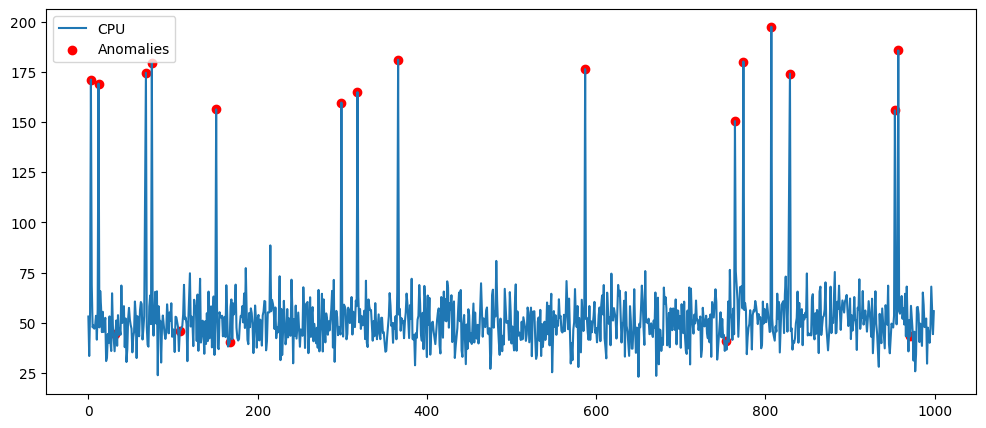

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["cpu"], label="CPU")
plt.scatter(
    anomalies.index,
    anomalies["cpu"],
    color="red",
    label="Anomalies"
)
plt.legend()
plt.show()

9. Evaluation  cant be use for unsuperived

10. Save Model

In [19]:
import os
import joblib

os.makedirs("saved_models", exist_ok=True)

joblib.dump(model, "saved_models/isolation_forest.pkl")
joblib.dump(scaler, "saved_models/scaler.pkl")

['saved_models/scaler.pkl']

11. Predict on New Input

In [ ]:
import pandas as pd

new_data = pd.DataFrame({
    "cpu": [85],
    "memory": [72],
    "latency": [250],
    "error_rate": [4],
    "hour": [14],
})

new_data["system_load"] = (
    new_data["cpu"] + new_data["memory"]
) / 2

new_scaled = scaler.transform(new_data)

prediction = model.predict(new_scaled)

prediction = model.predict(new_scaled)

if prediction[0] == -1:
    print("Anomaly detected")
else:
    print("System is healthy")

Anomaly detected
